# Pump Sizer
This code is to outline a preliminary sizing methodology for centrifugal pumps of similar architecture to what is currently used for the subscale LOx EPump and will likely be used for both Fullscale EPumps. it uses 1d analyses and correlations to reach system level rpm and general dimensioning that is optimal. After the sizer is used, higher level analysis, including Rotordynamics, CFD, and FEM can be preformed. This script makes many assumptions (Chief of which is that the architecture is set), makes large simplifications, and makes use of a many correlations, some of which do not apply to our exact situation. This code is therefore not flawless; in the results section, we will go over the different methods for sizing and how they compare. This code is also currently not finished, and a list of tasks is included below.

### In Progress
##### Quality of Life
1. adding comments for explanation to each python file
##### Technical
2. Bearing Selector, have it and seal dimensions be an output
3. Add shaft layout, incorporate to radial force calcs
4. Check for lox vaporization in the bearings
5. Prove that additional loops are unnescessary by plotting how much it changes with each iteration
6. Validate seal model (contact company for actual numbers)
7. Figure out actual dp through bearings and annulus to get more accurate seal inlet pressure value, (system for anullus and orifice?)
8. fix the hydraulic efficiency double count
9. single volute for radial forces
10. incorporate more precise axial thrust calculators (not yet written)
11. output recirc mdot



### Layout
The Code has the following layout:

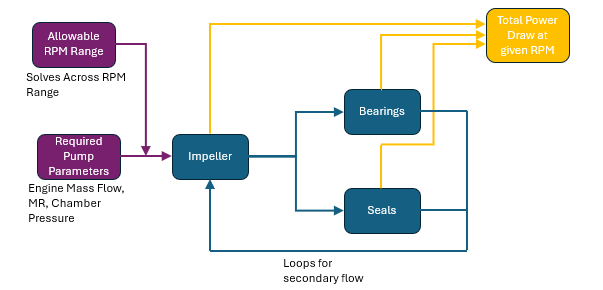

In [1]:
from IPython.display import Image, display
display(Image(filename="Pump Guide Images\\layout.png"))

The general purpose of the sizer is to find which RPM the pump with the given performance parameters will have the lowest power draw at. At each RPM, a new pump must be sized (only the parts that affect our simple efficiency calcs). The impeller is sized first, because it has the biggest effect on the downstream components. The bearings and the seal come after that, and then the necessary loops are performed to converge a design.

There are therefore five files, one for each section
1. define Impeller
2. defineBearing
3. defineSeal
4. power, which performs the loops and finds the overall power draw
5. Optimizer, which contains the optimizer itself and will output the final design values

There is also a subfolder that contains the original form of this script, which just plotted power draw against an RPM range, but that is outdated and all information in there will eventually be moved to here.

#### Inputs
The code takes in external inputs that it then uses to run the rest of the script. They are as follows:
1. RPM: This allows for an upper and lower bound for the optimizer. We do not wan't a pump running at 1 million RPM, nor do we want a pump running at 1 RPM. Therefore, we input an acceptable range. This will likely be in the 10k - 30k range, as below that things start to become too big and above that we start reaching problems with critical speeds and COTS component options. Currently, the upper limit is set for 23k, as that is where coupling sizing takes a large leap up. Note that this is defined in Optimizer.py, not the external run command.
2. Engine mass flow rate and mixture ratio. This allows us to go from vehicle level (more specifically, engine) to the volumetric flow rate needed in the pump
3. Propellant identity. Right now only RP1 and LOx are supported
4. DeltaP. This is a similar one which we take from the vehicle level, and then turn into a pump design parameter (Head)
5. Tank Pressure. This one is only needed to find state properties like density or viscosity, as the outlet pressure is P_tank + dP


## Impeller

#### Hydraulic Efficiency


Hydraulic efficiency is the rate at which the power added to the shaft (excluding the parasitic losses) is actually transfered into the fluid. Worth noting here, as well as many other places in this guide is that the hydraulic efficiency correlation used here, which is the backbone of the whole script, does not exactly apply to our pump -- it only applies to Q > .005. m^3/s However, I haven't bee able to find another choice for this low level analysis. The best way to see this is through the plot in Gulich's pumps where they show this relationship:

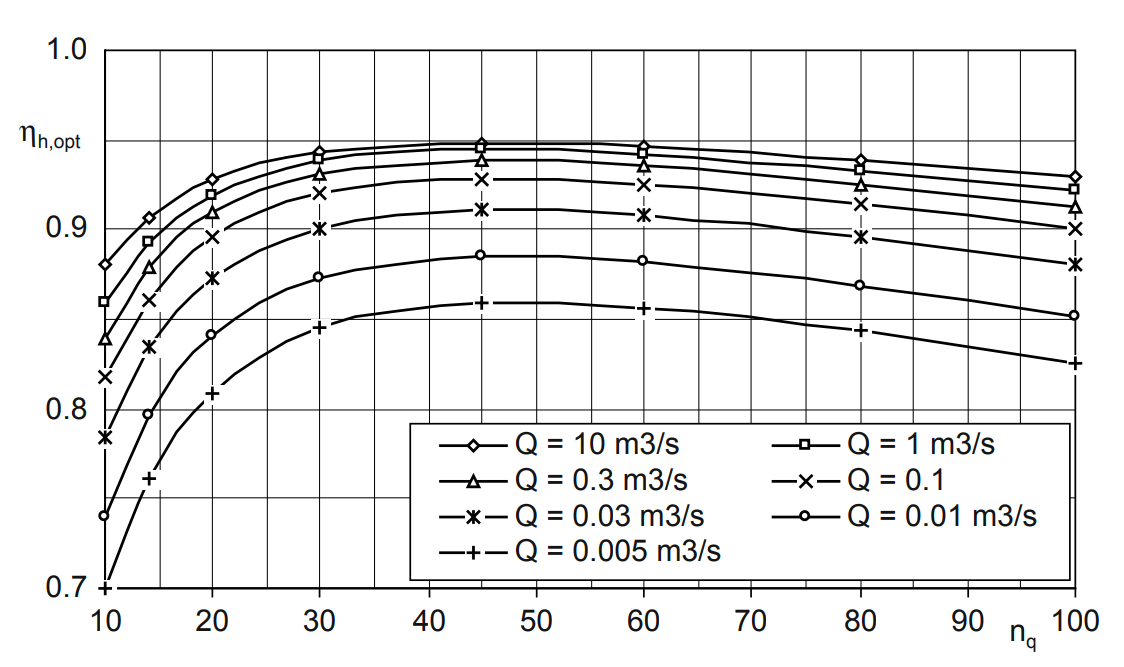

In [2]:
from IPython.display import Image, display
display(Image(filename="Pump Guide Images\\EtaH.png"))

as flowrate is set, and power is equal to $$ \rho g H Q $$we must adjust the impeller dimensions to account for the lack of head that will be generated. As diameter scales with the square root of head, the relationship is not incrediblly pronounced. However, at low RPMs (and therefore low specific speeds, which is what hydraulic efficiency is correlated against), the difference is very large as the impeller diameter must make up for a very large Head defecit. There is a small fudge factor applied to this shift in order to make the adjusted diameter more in line with what is observed when doing this on CFturbo, as they have access to more validated models than we do. This is, however, not modelled as an increase in required head, as that would lead to a double counting of the hydraulic efficiency. It is instead used for the calculation of the hydraulic forces, which is discussed below.

#### Disk Friction Losses
Disk friction losses come from the shear forces generated by the fluid on the impeller. The value can vary due with different sidewall gaps, as they generate different shaped boundary layers. As the math to derive these losses are very complicated, we use a more simplified calculation that finds them as a percentage of the useful power in the fluid. They also vary with the reynolds number, but we for both pumps are typically in the regime where the turbulent form of the equation is used. We have an assumed constant sidewall gap dimension, which comes from recommendations in Gulich'

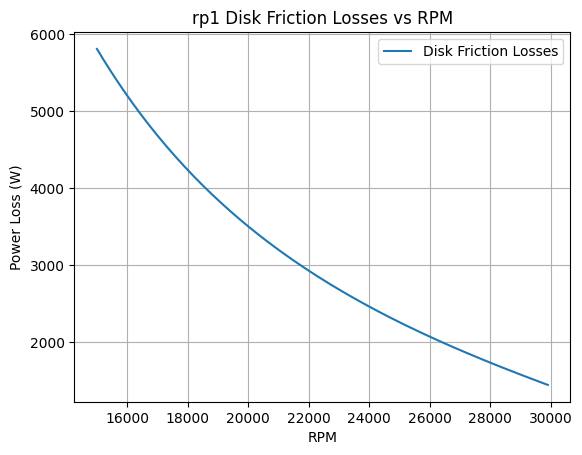

In [3]:
from powerDraw import pumpPowerNotebook
from matplotlib import pyplot as plt

n_vals = range(15000, 30000, 100)
prop="rp1"
deltaP=395
mdot=4.84
MR=2.2
p_in=135

vec = [prop, deltaP, mdot, MR, p_in]
vals = []
for n in n_vals:
    x = (n,1)
    _,impeller2,_,_ = pumpPowerNotebook(x,vec)
    vals.append(impeller2.Prr)
plt.figure()
plt.plot(n_vals, vals, label="Disk Friction Losses")
plt.xlabel("RPM")
plt.ylabel("Power Loss (W)")
plt.title(f"{prop} Disk Friction Losses vs RPM")
plt.grid(True)
plt.legend()
plt.show()

#### Hydraulic Forces
There are hydraulic forces acting on impeller due to static pressure imbalances. These are in turn transmitted to the bearings which must bear the loads, resulting in an increase in friction and therefore power loss. These forces are modelled using simplified methods given in Gulich's

However, we must account for the necessary upsizing in impeller diameter from the hydrualic efficiency. As mentioned earlier, is done by taking the actual head rise used in the impeller outer diameter equation, and dividing it by (eta_H * 1.15). This adds an increased target for the impeller to hit, as if the head rise is too low there is no guarentee simply increasing RPM will allow us to reach the head requirement. The 1.15 is to account for how using a flat increase by the hydraulic efficiency outputs a much larger impeller than cfturbo, and we will likely go with the outer diameter derived by cfturbo instead of the one from here. 

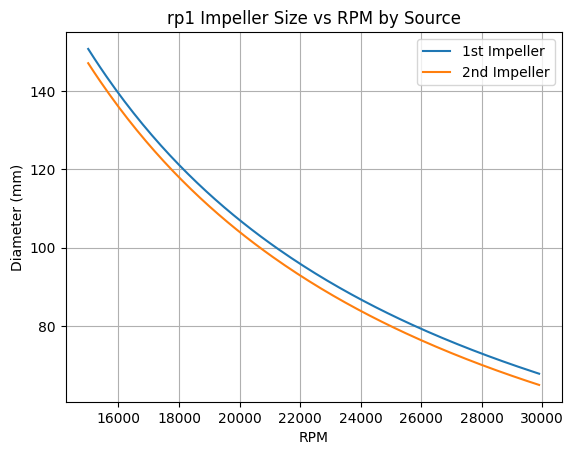

In [4]:
from powerDraw import pumpPowerNotebook
from matplotlib import pyplot as plt

n_vals = range(15000, 30000, 100)
prop="rp1"
deltaP=460
mdot=6.17
MR=2.23
p_in=135

vec = [prop, deltaP, mdot, MR, p_in]
imp1_vals = []
imp2_vals = []
imp3_vals = []
for n in n_vals:
    x = (n,1)
    impeller1,impeller2,_,_ = pumpPowerNotebook(x,vec)
    imp1_vals.append(impeller1.d_2)
    imp2_vals.append(impeller2.d_2)

imp1_vals = [1000*v for v in imp1_vals]
imp2_vals = [1000*v for v in imp2_vals]

plt.figure()
plt.plot(n_vals, imp1_vals, label="1st Impeller")
plt.plot(n_vals, imp2_vals, label="2nd Impeller")
plt.xlabel("RPM")
plt.ylabel("Diameter (mm)")
plt.title(f"{prop} Impeller Size vs RPM by Source")
plt.grid(True)
plt.legend()
plt.show()

##### Radial Forces
The model for radial forces assumes that we will be using a double volute. Eventually we should add single volute to the code, as it is still an open trade. This is important because the pressure imbalance that creates the radial force comes from a difference in static pressure at the outlets, which leads to a net force being created in one direction on the impeller. The image below gives a good visualization, as it looks from the top down onto an impeller and volute.

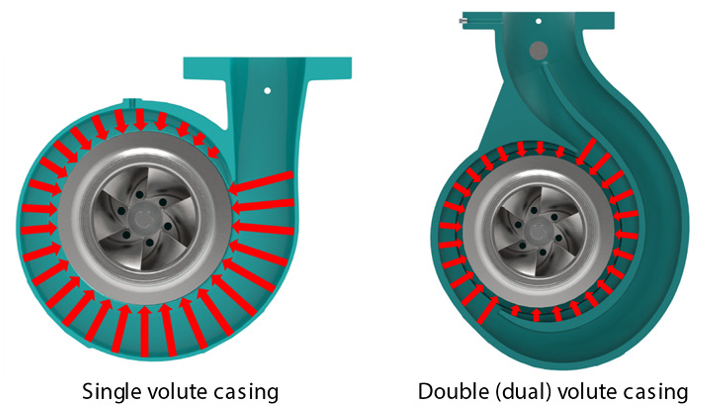

In [5]:
from IPython.display import Image, display
display(Image(filename="Pump Guide Images\\Radial Forces.png"))

In Gulich's, there are two types of radial forces: steady, and unsteady. We elect to sum both, in order to get the most conservative load on the bearings. Both of these forces are found by multiplying head, gravity, density, and the outlet area times a factor for the radial force. In the case of the steady force, as we are using a double volute, the correlation for the radial force factor comes from empirical data and the wrap angle of the volute. If we were to use a single volute, it would also depend heavily on the ratio of actual flowrate to design flowrate.

For the unsteady forces, the factor is simply given as a range between two numbers in Gulich's, .01 - .05 for all volutes at nominal conditions. We elect to use .05 to take the most conservative case. 

In the code below, we plot the steady radial force and unsteady radial force against RPM. Keep in mind that for all of the plots we are not assuming the same geometry; at each rpm, a new impeller is sized. As you can see, it trends downwards with RPM. This is likely because of the decreasing impeller size as Head requirements stay the same but speed increases.

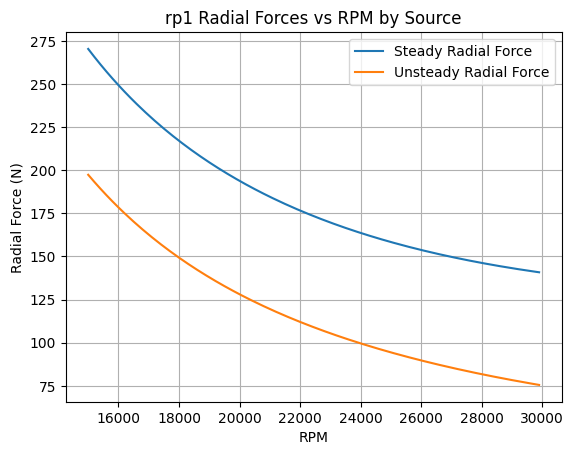

In [6]:
from powerDraw import pumpPowerNotebook
from matplotlib import pyplot as plt

n_vals = range(15000, 30000, 100)
prop="rp1"
deltaP=395
mdot=4.84
MR=2.2
p_in=135

vec = [prop, deltaP, mdot, MR, p_in]
steady_vals = []
unsteady_vals = []
for n in n_vals:
    x = (n,1)
    _,impeller2,_,_ = pumpPowerNotebook(x,vec)
    steady_vals.append(impeller2.F_Rst)
    unsteady_vals.append(impeller2.F_Rdyn)

plt.figure()
plt.plot(n_vals, steady_vals, label="Steady Radial Force")
plt.plot(n_vals, unsteady_vals, label="Unsteady Radial Force")
plt.xlabel("RPM")
plt.ylabel("Radial Force (N)")
plt.title(f"{prop} Radial Forces vs RPM by Source")
plt.grid(True)
plt.legend()
plt.show()

#### Axial Forces.
The axial forces in an impeller come from the pressure difference between the upper and lower shroud as well as the momentum difference in the incoming and outgoing fluid. They are influenced by the curl of the fluid, the pressure boundary conditions, and the gaps between the impeller and the sidewalls. There is large uncertainty in the calculation, due to the partload recirculation and the leakage flow rates. We elect not to use axial thrust correction, for multiple reasons. Firstly, reducing them to zero and not having the shaft always be under tension introduces the possibility of thrust reversal, which although not catastrophic due to our double AC bearing layout, is still problematic. Thrust correcting also adds significant modelling, testing, and integration complexity.

Due to the complexity of calculating all these effects, we instead use an estimate listed in Gulich's where it is similar to the equation used for radial forces, except the factor is fixed at .9 and it is scaled by the difference in diameters. 

The axial force is plotted below over RPM ranges. Due to the constant nature of everything in the equation besides the geometry, the local minimum is derived from the sizing of the inlet and outlet diameters.

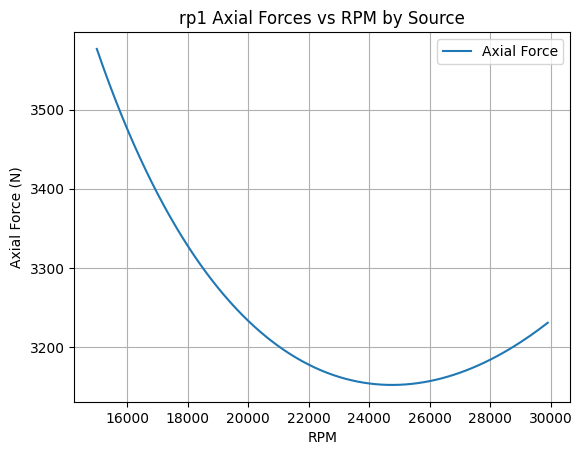

In [7]:
from powerDraw import pumpPowerNotebook
from matplotlib import pyplot as plt

n_vals = range(15000, 30000, 100)
prop="rp1"
deltaP=395
mdot=4.84
MR=2.2
p_in=135

vec = [prop, deltaP, mdot, MR, p_in]
force_vals = []
for n in n_vals:
    x = (n,1)
    _,impeller2,_,_ = pumpPowerNotebook(x,vec)
    force_vals.append(impeller2.f_ax)

plt.figure()
plt.plot(n_vals, force_vals, label="Axial Force")
plt.xlabel("RPM")
plt.ylabel("Axial Force (N)")
plt.title(f"{prop} Axial Forces vs RPM by Source")
plt.grid(True)
plt.legend()
plt.show()

## Bearings

Bearings are a large source of power loss in this model. Because there is a load applied to the bearings, namely the axial and radial forces, and the bearings have non-negligible friction, some amount of power is drawn by them while the pump is operating. The full description of how this math is done can be found <a href="https://cdn.skfmediahub.skf.com/api/public/0901d1968065e9e7/pdf_preview_medium/0901d1968065e9e7_pdf_preview_medium.pdf" target="_blank">
Here. 
</a>

In the code, this takes the form of defining our bearing object based some inputs. They are:
1. Bearing Type
2. propellant starting temperature
3. allowable temperature change across the bearing
4. propellant identity
5. pressure at the exit of the impeller

We need to know the bearing type because that defines how the bearing will end up taking the load. We have an assumed layout for the pump, where there is an "upper" pair of angular contact bearings, and a "lower" deep groove ball bearing. It is assumed that the upper bearings will take all of the axial load, due to them being AC bearings, while the radial load is split up as if the shaft is a cantilevered beam with the load being applied at the impeller. The propellant temperature matters, as we are assuming flooded upper bearings, and the viscosity (and therefore lubrication performance) varies with temperature. The allowable temperature change is defined by us. This method comes from a nasa file and the selected allowable temp is included in the overall sizing loop because it contains a trade: higher allowable temperature change means less flow and therefore less useful power draw, but also lowers lubrication performance. The pressure is needed for the liquid oxygen viscosity coolProp call. 

The friction is divided into three components. The first is rolling, which happens because the balls deform slightly and form an elliptical contact patch, meaning that different parts of the ball are moving relative to the rings at different speeds. Next is the sliding moment. That comes because the ball bearings will not always be rolling at the exact rpm necessary. Finally, there is drag due to the lubricant. This is large for us due to using flooded bearings, but this model might be overconservative as it doesn't account for incoming swirl that will be generated by the impeller. The math is derived from the skf method, that comes from large amounts of correlations. 

The power draw of the lower bearings is assumed to be a flat 50 watts. This is because, due to the presence of the mechanical seal between the upper and lower bearings, we believe we can apply a lubricant and not have it get swept away by any propellant flow. The number 50 comes from the skf website for power draw, and it is so marginal compared to the rest of the power losses that it is left constant. 

for the upper bearings, certain simplifications are made to allow for more rapid calculations. For now, the dimensions and parameters are set, matching the bearing selected for the fuel pump on notion. In the future, some form of simple bearing selector could be used. 

We can plot the power loss over time of the upper bearings to see how it scales:

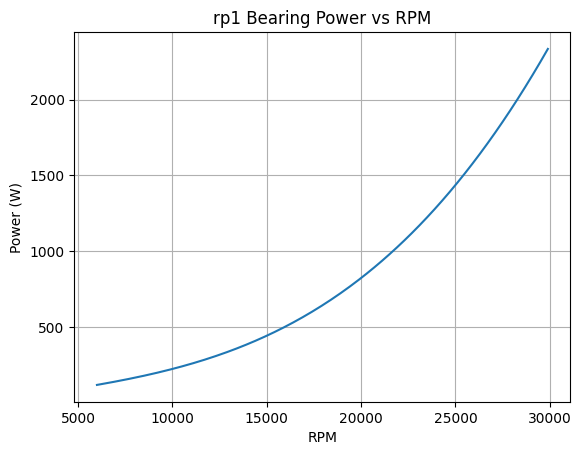

In [8]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt


example = bearingClass("AC",300,3,"rp1",360,135) # remember to change temperature (2nd input) by propellant (300 for rp1, 90 for lox)
example.bearingPlot("AC", 3000, 500)
# The last two arguments are axial and radial forces in Newtons

We can also plot the power loss caused by the various components of friction in order to see which is most significant:

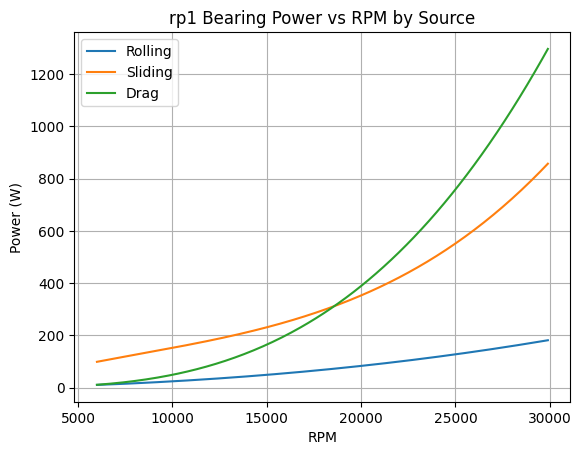

In [9]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt


example = bearingClass("AC",300,3,"rp1",360,135)
example.bearingSourcePlot("AC", 3000, 500)


This makes a decent amount of sense. Drag should have the highest dependence on rpm, as it moves with velocity squared. Rolling has the lowest dependency on rpm, because it happens mainly due to the pressure and the contact ellipse that is formed, creating a smaller, more constant difference in velocity between the balls and the rings. If you convert this bearing type to lox (or view the plots in the appendix), you will see that for lox the drag is lower than sliding across our whole range. This is because the viscosity of lox is almost an order of magnitude lower than the viscosity of rp1

Next, we can compare the sources of friction over various temperature changes to see if the effect matches our intuition.

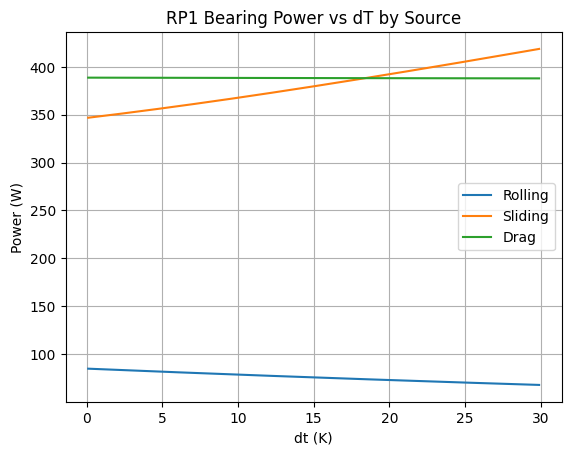

In [10]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt

dt_vals = range(1, 300, 1)
dt_vals = [dt/10 for dt in dt_vals]
proll_vals = []
pslide_vals = []
pdrag_vals = []
for dt in dt_vals:
    example = bearingClass("AC",300,dt,"rp1",360,135)
    example.heating("AC", 20000, 3000, 500)
    proll_vals.append((1.05*(10**(-4)))*(example.M_rr2+example.M_rr)*20000)
    pslide_vals.append((1.05*(10**(-4)))*(example.M_sl2+example.M_sl)*20000)
    pdrag_vals.append((1.05*(10**(-4)))*(example.M_drag2+example.M_drag)*20000)


plt.figure()
plt.plot(dt_vals, proll_vals, label="Rolling")
plt.plot(dt_vals, pslide_vals, label="Sliding")
plt.plot(dt_vals, pdrag_vals, label="Drag")
plt.xlabel("dt (K)")
plt.ylabel("Power (W)")
plt.title("RP1 Bearing Power vs dT by Source")
plt.grid(True)
plt.legend()
plt.show()

This generally follows engineering intuition as it makes sense that the drag component decreases with a decrease in viscosity, but overall there is very little change due to the small magnitude of change in viscosity; For now we choose to continue with this model.

## Seals

For now, we assume that the seal used in this is the John Crane 5xB series seals that have been selected and described on notion. Overall this is the section of the code that makes the most simplifying assumptions without validation. 

The first of these is that the inner diameter is assumed to be the same as the upper bearing's inner diameter. This is not too bad of an assumption, and likely what will happen in real life. Another assumption made that is likely not too terrible is that there will be a 200 psi pressure drop in the bearings. This is a gut instinct play, and once an actual fluid network is constructed for the bearing coolant flow path a more accurate assumption should be made

The main assumption that is invalidated has to do with the spring pressure. As the seal we want to use does not include that information in the data sheet. The spring pressure must be known to solve for the net face pressure, which drives the friction of the seal. Therefore, we must go with values that seem reasonable. In the paper where this method is shown, there is an example where the spring pressure has a value of 35% of the other pressures. We therefore apply a flat 1.35x multiplier to the net pressure value. 

We can plot the effect of the seal and see how it performs against RPM for both fluids (as this model is independent of fluid properties):

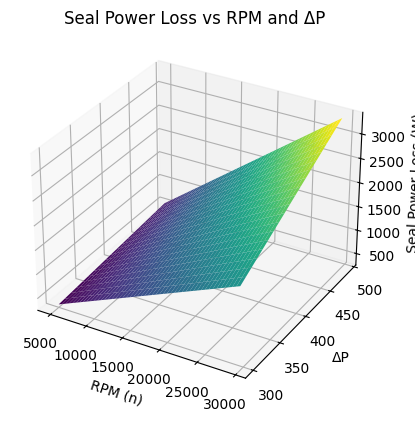

In [11]:
from defineSeal import sealClass
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
n_vals = np.arange(5000, 30000, 500)
dp_vals = np.arange(300, 500, 10)
dp_vals = dp_vals * 6894.76  # convert to Pa
N, DP = np.meshgrid(n_vals, dp_vals)
P = np.zeros((len(dp_vals), len(n_vals)))
for i, dp in enumerate(dp_vals):
    for j, n in enumerate(n_vals):
        ex = sealClass(20, dp, 135)
        ex.powerLoss(n)
        P[i, j] = ex.p

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

DP = DP / 6894.76  # convert back to psi for labeling
surf = ax.plot_surface(N, DP, P, cmap='viridis')

ax.set_xlabel("RPM (n)")
ax.set_ylabel("ΔP")
ax.set_zlabel("Seal Power Loss (W)")
ax.set_title("Seal Power Loss vs RPM and ΔP")

plt.show()
        

## Coolant Flow
The coolant flow method comes from a nasa paper linked on the notion. It starts with an assumed allowable change in temperature of the propellant, and then uses a heat capacity (assumed constant for rp1, coolprop for lox) to find the total mass flow rate. The equation is therefore $$ \dot m = \frac{Q}{C_p * \Delta T}$$ We then add the new volumetric flowrate to the old volumetric flowrate to design the new useful power requirement (and resize specific speed to estimate a new hydraulic efficiency) That means there are three seperate impellers that get sized, albeit only the outer diameter and some other simple dimensions. We can plot these against the rpm to see how much they vary on average. Note that the seal flow rate is not counted for here: the seal power loss largely goes into vaporizing the fluid film between the inner and outer sections, and it is held at temp by the fluid that goes past it through the bearings, although this should probably be double checked. 

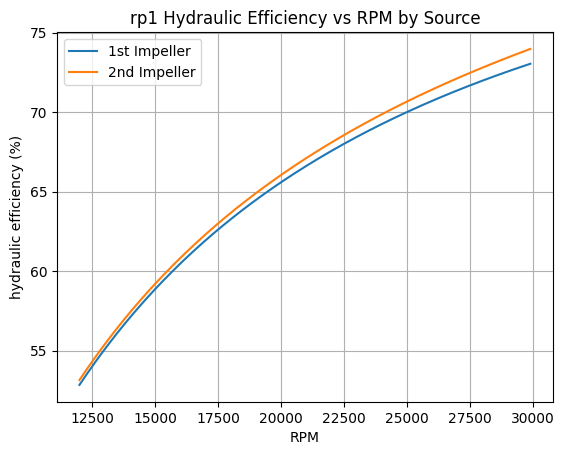

In [12]:
from powerDraw import pumpPowerNotebook
n_vals = range(12000, 30000, 100)
prop="rp1"
deltaP=460
mdot=6.17
MR=2.23
p_in=135

vec = [prop, deltaP, mdot, MR, p_in]
imp1_vals = []
imp2_vals = []
imp3_vals = []
for n in n_vals:
    x = (n,10)
    impeller1,impeller2,_,_ = pumpPowerNotebook(x,vec)
    imp1_vals.append(impeller1.eta_H)
    imp2_vals.append(impeller2.eta_H)

imp1_vals = [100*v for v in imp1_vals]
imp2_vals = [100*v for v in imp2_vals]
imp3_vals = [100*v for v in imp3_vals]

plt.figure()
plt.plot(n_vals, imp1_vals, label="1st Impeller")
plt.plot(n_vals, imp2_vals, label="2nd Impeller")
plt.xlabel("RPM")
plt.ylabel("hydraulic efficiency (%)")
plt.title(f"{prop} Hydraulic Efficiency vs RPM by Source")
plt.grid(True)
plt.legend()
plt.show()

it makes sense that the second impeller has almost a perpetually lower efficiency than the first. That is because it applies scales for efficiency (with a small adjustment) to get a new head requirement, meaning it has a lower specific speed, correlating to a lower efficiency. Then, to get to the third impeller, a flowrate increase is applied for the bearing recirculation, leading to a reversal of the prior effect.

The required CdA for the coolant flow can be calculated rather easily:

In [13]:
from powerDraw import pumpPowerNotebook
prop="rp1"
deltaP=460
mdot=6.17
MR=2.23
p_in=135
vec = [prop, deltaP, mdot, MR, p_in]
x = (25000,1)
_,_,Qcooling,_ = pumpPowerNotebook(x,vec)
rho = 804.59
mdot = Qcooling * rho
CdA = mdot / ((2*rho*deltaP*6894.76)**0.5)
print(f"Required CdA: {CdA} m^2")





Required CdA: 9.927776592873074e-06 m^2


# Results
The general way to run the script is as follows: In order to resize the impeller to begin the epump sizing workflow, change the values in the notebook to see the new optimal rpm and power draw. The runner.ipnyb notebook has a more compact format so that iterating can be done faster and easier.

In [14]:
from Optimizer import run_epump
results = run_epump(
    prop="rp1",
    deltaP=395,
    mdot=4.84,
    MR=2.2,
    p_in=140
)


Pump Sizing Results
---------------------------------------------
RPM                           :        2e+04
flow rate (m^3/s)             :     0.002007
DeltaT (K)                    :        3.882
Head (m)                      :          345
Specific Speed                :        11.19
Reynold's number              :    9.975e+06

Pump Power Results
---------------------------------------------
Power Draw (W)                :    1.466e+04
Gulich's power(W)             :    1.867e+04
Available Power (W)           :      1.6e+04
hydraulic Power (W)           :         8471
Hydraulic Efficiency          :       0.6452
Mechanical Parasitic Power (W):         2666
Disk Friction Losses (W)      :         3518


In [15]:
from Optimizer import run_epump
results = run_epump(
    prop="lox",
    deltaP=295,
    mdot=4.84,
    MR=2.2,
    p_in=140
)




Pump Sizing Results
---------------------------------------------
RPM                           :    1.674e+04
flow rate (m^3/s)             :     0.003229
DeltaT (K)                    :            1
Head (m)                      :        180.5
Specific Speed                :        19.32
Reynold's number              :    6.188e+07

Pump Power Results
---------------------------------------------
Power Draw (W)                :    1.143e+04
Gulich's power(W)             :    1.235e+04
Available Power (W)           :    1.339e+04
hydraulic Power (W)           :         8434
Hydraulic Efficiency          :       0.7787
Mechanical Parasitic Power (W):         1749
Disk Friction Losses (W)      :         1245


### Workflow
The idea for the worklfow is to start with this 1 dimensional script. Inputting values gained from the vehicle sizer will allow us to take this design into further iterations. After initial values are gained from here, more accurate results can be pursued and reinputted into the vehicle sizer to see if altitude is still being reached. Therefore the general workflow for just pumps is as follows:

1. get results from vehicle sizer, input into runner.ipnyb.From that, the results that matter are: RPM, DeltaT, Mechanical Power Loss, Hydraulic Efficiency
2. We create an impeller in cfturbo according to sizer guidelines. We need: Geometry, Pump Curve
3. Then, We move on to higher fidelity models. CFD is done to get actual hydraulic efficiency numbers.If created, the more precised bearing calculator is used to improve the bearing estimates, which can then be added to the seal losses from here
4. From that we give to the rest of powerhead:General dimensions (i.e. volute sizes, shaft length), and Pump Curve from CFturbo or CFD
5. We give to the vehicle sizer power draw, and powerhead gives them general performance parameters. i.e. mass flow rate, thrust.


#### Method Comparison
This is one of the three different methods for sizing the impeller. The other methods rely wholly on the correlations from Gulich's. The first alternate method is to apply a flat transformation to the hydraulic power, which matches what I've seen in some simple approximations in industry. The next is to use the Gulich's correlation for overall efficiency. I like these less, even though they have more validation behind them, as they apply less specifically to our situation. We can compare these by plotting them against rpm (again keeping deltaT constant)

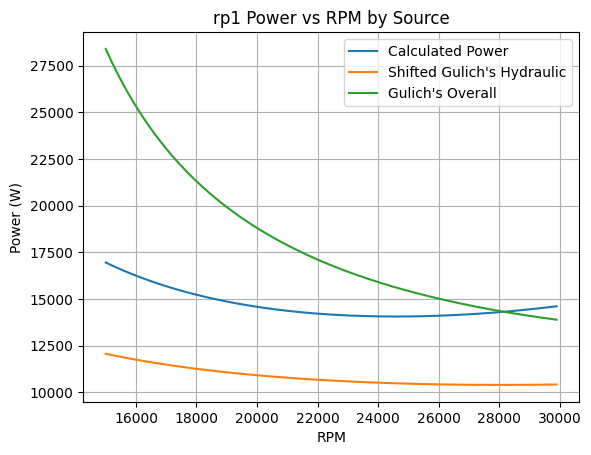

In [16]:
from powerDraw import pumpPowerNotebook
n_vals = range(15000, 30000, 100)
prop="rp1"
deltaP=395
mdot=4.84
MR=2.2
p_in=140

vec = [prop, deltaP, mdot, MR, p_in]
pcalc_vals = []
phgul_vals = []
pogul_vals = []
for n in n_vals:
    x = (n,5)
    _,impeller2,_,p = pumpPowerNotebook(x,vec)
    pcalc_vals.append(p)
    phgul_vals.append(1.3*impeller2.p/impeller2.eta_H)
    pogul_vals.append(impeller2.p/impeller2.eta_opt)

plt.figure()
plt.plot(n_vals, pcalc_vals, label="Calculated Power")
plt.plot(n_vals, phgul_vals, label="Shifted Gulich\'s Hydraulic")
plt.plot(n_vals, pogul_vals, label="Gulich\'s Overall")
plt.xlabel("RPM")
plt.ylabel("Power (W)")
plt.title(f"{prop} Power vs RPM by Source")
plt.grid(True)
plt.legend()
plt.show()

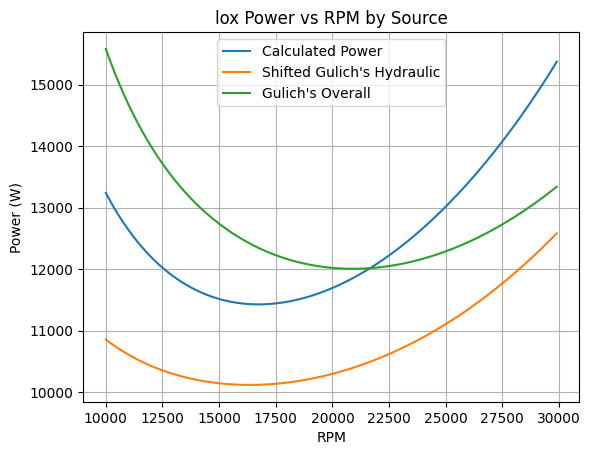

In [17]:
from powerDraw import pumpPowerNotebook
n_vals = range(10000, 30000, 100)
prop="lox"
deltaP=295
mdot=4.84
MR=2.2
p_in=140

vec = [prop, deltaP, mdot, MR, p_in]
pcalc_vals = []
phgul_vals = []
pogul_vals = []
for n in n_vals:
    x = (n,1)
    _,impeller2,_,p = pumpPowerNotebook(x,vec)
    pcalc_vals.append(p)
    phgul_vals.append(1.2*impeller2.p/impeller2.eta_H)
    pogul_vals.append(impeller2.p/impeller2.eta_opt)

plt.figure()
plt.plot(n_vals, pcalc_vals, label="Calculated Power")
plt.plot(n_vals, phgul_vals, label="Shifted Gulich\'s Hydraulic")
plt.plot(n_vals, pogul_vals, label="Gulich\'s Overall")
plt.xlabel("RPM")
plt.ylabel("Power (W)")
plt.title(f"{prop} Power vs RPM by Source")
plt.grid(True)
plt.legend()
plt.show()

The range for rpm is a much smaller rpm range because the overall efficiency increases rapidly as rpm decreases past this point. It's also worth noting that both Gulich's efficiency's scale nonlinearly, not just because of the equation but because the head is increased for lower efficiency, meaning it is somewhat double counted. Problematically, all of these show vastly different minimum points. Although the additional precision added in this script does not neccesarily equate to more accuracy, the increase in specificity does lend itself to viewing this calculation more positively. For that reason, we elect to continue using this calculator.

#### Bearing DeltaT
We can also plot the results for a fixed RPM across varying changes in temperature to see their effect. After running multiple times, The most optimal typically seems to be the highest allowed, except for some LOx cases where it is just near the highest. For rp1, it is likely that we will allow for a relatively high temperature change, likely on the order of 5-10 kelvin, although that is an estimate. For LOx, we will likely only allow for a 1 degree change, as gox formation has the potential to be catastrophic. We can find where gox forms in the bearings by doing a coolprop call for viscosity at the estimated bearing pressures, varying it across temperature. The viscosity fails to be called at around 140 K, giving us a potential max deltat of 50 K. However, this fails to account for localized regions of very low pressure and high temperature at bearing contact areas, so is wildly underconservative.

When plotting the power draw against temperature change, you can see that it starts to asymptote at very low temperature changes. This is because it would require an infinitely high flowrate to create a 0 K change. I also plotted hydraulic effiency against delta T, and you can see that even in the design range it has a non-negligible effect due to the flowrate increase.

Temperature: 90, Viscosity: 1.734351157320246e-07
Temperature: 91, Viscosity: 1.6893872602367694e-07
Temperature: 92, Viscosity: 1.6462061771660717e-07
Temperature: 93, Viscosity: 1.604696379399788e-07
Temperature: 94, Viscosity: 1.5647542904897682e-07


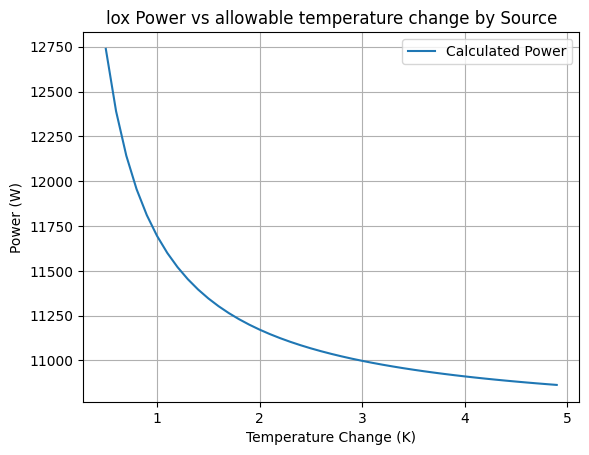

In [18]:
from powerDraw import pumpPowerNotebook
from CoolProp.CoolProp import PropsSI
prop="lox"
deltaP=295
mdot=4.84
MR=2.2
p_in=140
for t in range(0, 5, 1):
    visc = PropsSI('V','T',90+t,'P|liquid',(p_in+deltaP-200)*6894.7,'Oxygen')/PropsSI("D","T",90,'P|liquid',(p_in+deltaP-200)*6894.7,'Oxygen')
    print(f"Temperature: {90+t}, Viscosity: {visc}")

pvals =[]
tvals = []
for t in range(5, 50, 1):
    t = t/10
    x = (20000,t)
    _,impeller2,_,p = pumpPowerNotebook(x,vec)
    pvals.append(p)
    tvals.append(t)

plt.figure()
plt.plot(tvals, pvals, label="Calculated Power")
plt.xlabel("Temperature Change (K)")
plt.ylabel("Power (W)")
plt.title(f"{prop} Power vs allowable temperature change by Source")
plt.grid(True)
plt.legend()
plt.show()


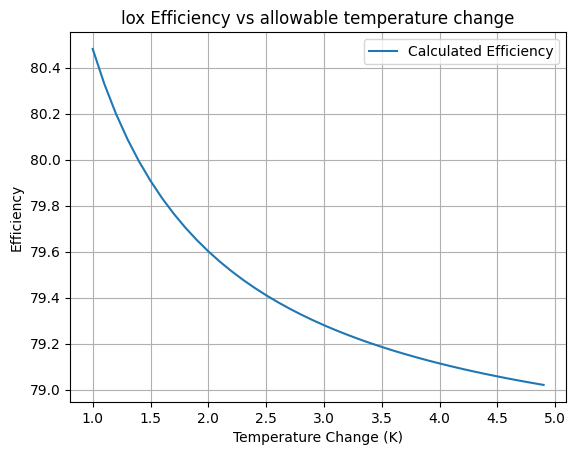

In [19]:
from powerDraw import pumpPowerNotebook
from CoolProp.CoolProp import PropsSI

evals =[]
tvals = []
prop="lox"
deltaP=295
mdot=4.84
MR=2.2
p_in=140
vec = [prop, deltaP, mdot, MR, p_in]
for t in range(10, 50, 1):
    t = t/10
    x = (20000,t)
    _,impeller2,_,_ = pumpPowerNotebook(x,vec)
    impeller2.eta_H = impeller2.eta_H*100
    evals.append(impeller2.eta_H)
    tvals.append(t)

plt.figure()
plt.plot(tvals, evals, label="Calculated Efficiency")
plt.xlabel("Temperature Change (K)")
plt.ylabel("Efficiency")
plt.title(f"{prop} Efficiency vs allowable temperature change")
plt.grid(True)
plt.legend()
plt.show()


### Issues

There are a couple issues that exist in this script/workflow. The main one is of course that pretty much every piece of "analysis" here comes from correlations and models that don't necessarily apply to this specific pump. Another one is how the model seems to break at some rpm ranges (likely coming from the gulich's correlation.) Those can be seen by doing a 3d plot through a larger range. (I have since commented this out, as what had been previously breaking the plot now breaks the whole script.)

In [20]:
#import numpy as np
#import matplotlib.pyplot as plt
#from mpl_toolkits.mplot3d import Axes3D

#n_vals = np.arange(2000, 30000, 100)
#deltat_vals = np.arange(10, 300, 10) / 10

#prop = "rp1"
#deltaP = 460
#mdot = 6.17
#MR = 2.23
#p_in = 135
#vec = [prop, deltaP, mdot, MR, p_in]

## plotting section
# Create meshgrid
#N, DT = np.meshgrid(n_vals, deltat_vals)
# Allocate p array
#P = np.zeros_like(N, dtype=float)
# Fill grid
#for i, dt in enumerate(deltat_vals):
#    for j, n in enumerate(n_vals):
#        x = (n, dt)
#        _, _, _, p = pumpPowerNotebook(x, vec)
#        P[i, j] = p

#fig = plt.figure()
#ax = fig.add_subplot(111, projection='3d')
#
#ax.plot_surface(N, DT, P, cmap='viridis')

#ax.set_xlabel("RPM (n)")
#ax.set_ylabel("Delta T")
#ax.set_zlabel("Power (W)")
#ax.set_title("Pump Power vs RPM and ΔT")
#print("Max Power:", max(P.flatten()))
#plt.show()


There is clearly something wrong here. My best guess as to what's happening is that the hydraulic efficiency is coming back negative, screwing up. The correlations are therefore definitively proven to be invalid at that range.

This has been corroborated by changing the method used to calculate impeller diameter. Initially, the impeller was upsized in powerDraw.py. However, as that led to double counting efficiencies by having eta_H be returned in both the overall power draw and the increased head requirements, I elected to move it into defineImpeller. To size the impeller outer diameter, you put the head requirement in the denominator of a fraction. However, as it scales with the square root of head, if you account for hydraulic efficiency but the sign of eta_H switches, you will recieve a math error. As that kept happening and breaking this section of the code, I have removed it. To see what the plot looks like when erroring, you can remove the second equation for d_2 in defineImpeller



## Appendix

#### Total Design Space

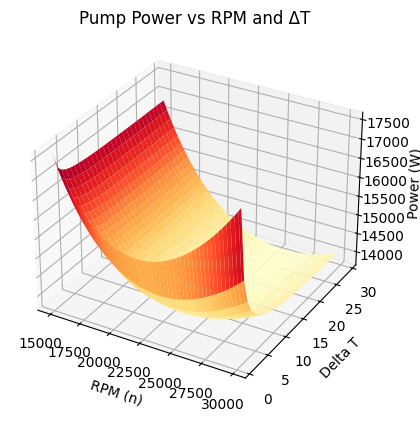

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

n_vals = np.arange(15000, 30000, 100)
deltat_vals = np.arange(10, 300, 10) / 10

prop = "rp1"
deltaP = 395
mdot = 4.84
MR = 2.2
p_in = 140
vec = [prop, deltaP, mdot, MR, p_in]

## plotting section
# Create meshgrid
N, DT = np.meshgrid(n_vals, deltat_vals)
# Allocate p array
P = np.zeros_like(N, dtype=float)
# Fill grid
for i, dt in enumerate(deltat_vals):
    for j, n in enumerate(n_vals):
        x = (n, dt)
        _, _, _, p = pumpPowerNotebook(x, vec)
        P[i, j] = p

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(N, DT, P, cmap='YlOrRd')

ax.set_xlabel("RPM (n)")
ax.set_ylabel("Delta T")
ax.set_zlabel("Power (W)")
ax.set_title("Pump Power vs RPM and ΔT")

plt.show()


#### Lox Bearing Plots

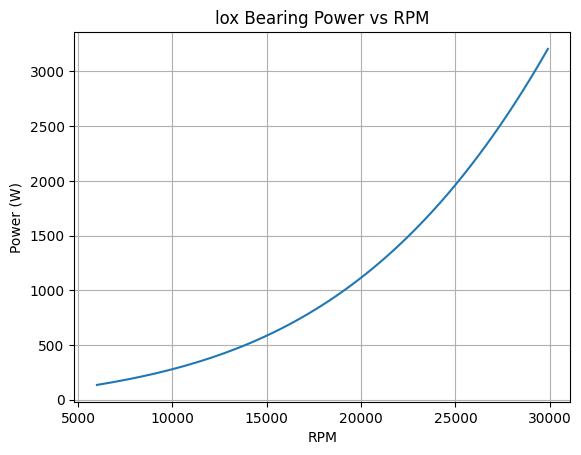

In [22]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt


example = bearingClass("AC",90,3,"lox",360,135) # remember to change temperature (2nd input) by propellant (300 for rp1, 90 for lox)
example.bearingPlot("AC", 3000, 500)
# The last two arguments are axial and radial forces in Newtons

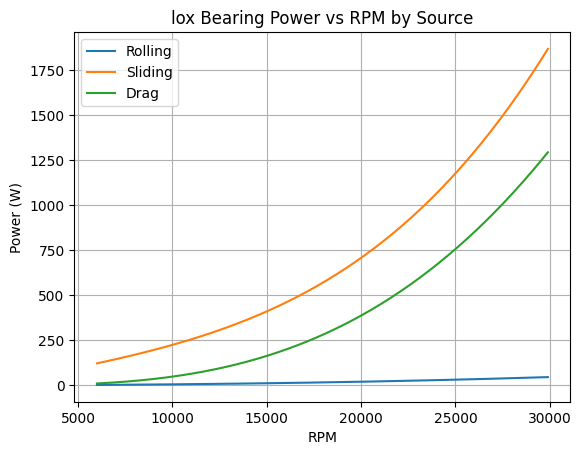

In [23]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt


example = bearingClass("AC",90,3,"lox",360,135)
example.bearingSourcePlot("AC", 3000, 500)


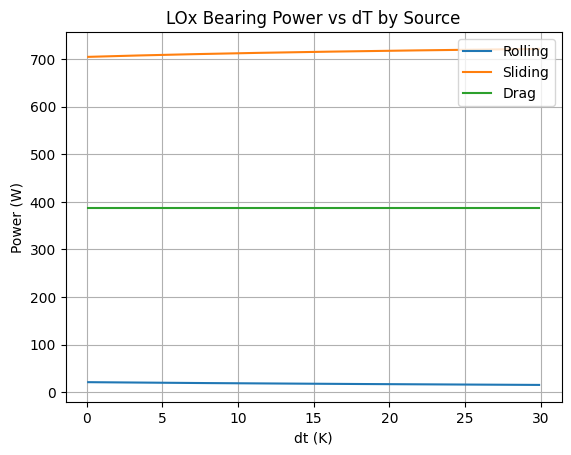

In [24]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt

dt_vals = range(1, 300, 1)
dt_vals = [dt/10 for dt in dt_vals]
proll_vals = []
pslide_vals = []
pdrag_vals = []
for dt in dt_vals:
    example = bearingClass("AC",90,dt,"lox",360,135)
    example.heating("AC", 20000, 3000, 500)
    proll_vals.append((1.05*(10**(-4)))*(example.M_rr2+example.M_rr)*20000)
    pslide_vals.append((1.05*(10**(-4)))*(example.M_sl2+example.M_sl)*20000)
    pdrag_vals.append((1.05*(10**(-4)))*(example.M_drag2+example.M_drag)*20000)


plt.figure()
plt.plot(dt_vals, proll_vals, label="Rolling")
plt.plot(dt_vals, pslide_vals, label="Sliding")
plt.plot(dt_vals, pdrag_vals, label="Drag")
plt.xlabel("dt (K)")
plt.ylabel("Power (W)")
plt.title("LOx Bearing Power vs dT by Source")
plt.grid(True)
plt.legend()
plt.show()

### Sources
[1]. Gulich, Centrifugal Pumps<br> 
[2]. Outcalt and Laesecke, Thermophysical Properties Measurements of Rocket Propellants RP-1 and RP-2, Journal of Propulsion and Power<br>
[3]. SKF, The SKF model for calculating the frictional moment<br>
[5]. Liquid Rocket Engine Turbopump Bearings, NASA Space Vehicle Design Criteria<br>
[6]. Kim, Kim, and Park, Analytical study about effects of kerosene lubrication on slip, heat, and temperature of a cylindrical roller bearing,Journal of Mechanical Science and Technology 37 <br>
[7]. Arnold and Fone, Mechanical Seal Power and Related Performance Calculations, Proceedings of the Twenty-Sixth International Pump User's Symposium<br>